# Phase 8 : Clustering

**Objective**

Discover naturally occurring lifestyle groups within the population using K-Means clustering and determine whether clustering performance improves when PCA-transformed features are used instead of the original standardized feature set.

**Hypothesis:**

* The original standardized 12-feature dataset will produce clustering quality that is equal to or slightly better than the 3-PC representation.
* Even if the metrics are very close, the original feature space will win because the resulting clusters can be explained in terms of meaningful lifestyle factors such as mental wellness, productivity, social wellness, and stress burden instead of abstract principal components.

<img src="./images/clustering_roadmap.png" width="500">

**Inputs**
* scaled_features.csv
* pca_features.csv

**Outputs**
* Optimal number of clusters
* Cluster assignments
* Cluster evaluation metrics
* Comparison report
* Final clustering dataset

**Expected Deliverables**

By the end of this notebook, we should answer:

* What is the optimal number of clusters?<br>
* Does PCA improve clustering?<br>
* Which representation should be used?<br>
* What are the characteristics of each cluster?

In [2]:
# Load datasets

import pandas as pd
import numpy as np

scaled_df = pd.read_csv("dataset//scaled_features.csv")
pca_df = pd.read_csv("dataset//pca_features.csv")

print("Scaled Dataset Shape :", scaled_df.shape)
print("PCA Dataset Shape    :", pca_df.shape)

Scaled Dataset Shape : (15489, 12)
PCA Dataset Shape    : (15489, 3)


# Elbow Method

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

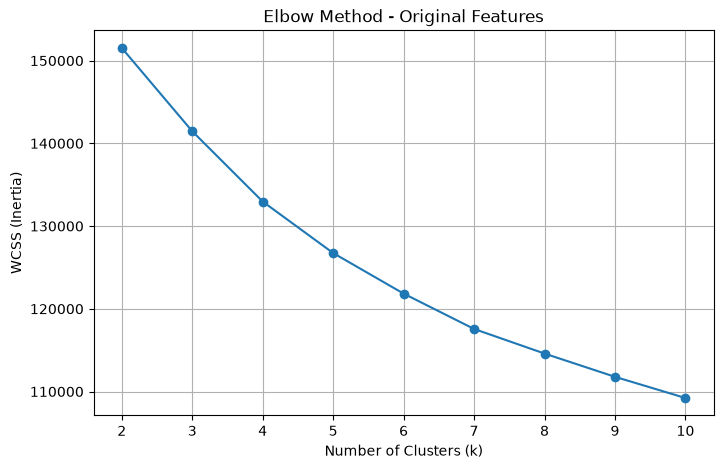

In [4]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method - Original Features")

plt.grid(True)

plt.show()

# Silhouette Analysis

| Score     | Meaning    |
| --------- | ---------- |
| >0.70     | Excellent  |
| 0.50–0.70 | Good       |
| 0.25–0.50 | Reasonable |
| <0.25     | Weak       |


# Comprehensive Cluster Evaluation

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

k_values = range(2, 11)

results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(scaled_df)

    results.append({

        "k": k,

        "WCSS": kmeans.inertia_,

        "Silhouette Score":
            silhouette_score(scaled_df, labels),

        "Davies-Bouldin Index":
            davies_bouldin_score(scaled_df, labels),

        "Calinski-Harabasz Index":
            calinski_harabasz_score(scaled_df, labels)

    })

evaluation_df = pd.DataFrame(results)

display(evaluation_df.round(4))

,k,WCSS,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,151526.5160,0.1606,2.0634,3509.9391
1,3,141460.6258,0.1068,2.4647,2430.7004
2,4,132962.6739,0.1021,2.3179,2053.8103
3,5,126739.0902,0.1042,2.2314,1805.9825
4,6,121837.5971,0.0953,2.2362,1627.3857
5,7,117564.2571,0.0965,2.2323,1499.1560
6,8,114590.2854,0.0914,2.3101,1375.6503
7,9,111777.8414,0.0910,2.2941,1282.5869
8,10,109217.9635,0.0937,2.1946,1207.0332


Maximum silhoutte score came out to be 0.16 which means that it is very weak clustering.

# Clustering Evaluation

**Ranking the Metrics**

* Silhouette → Higher is better
* Davies-Bouldin → Lower is better
* Calinski-Harabasz → Higher is better

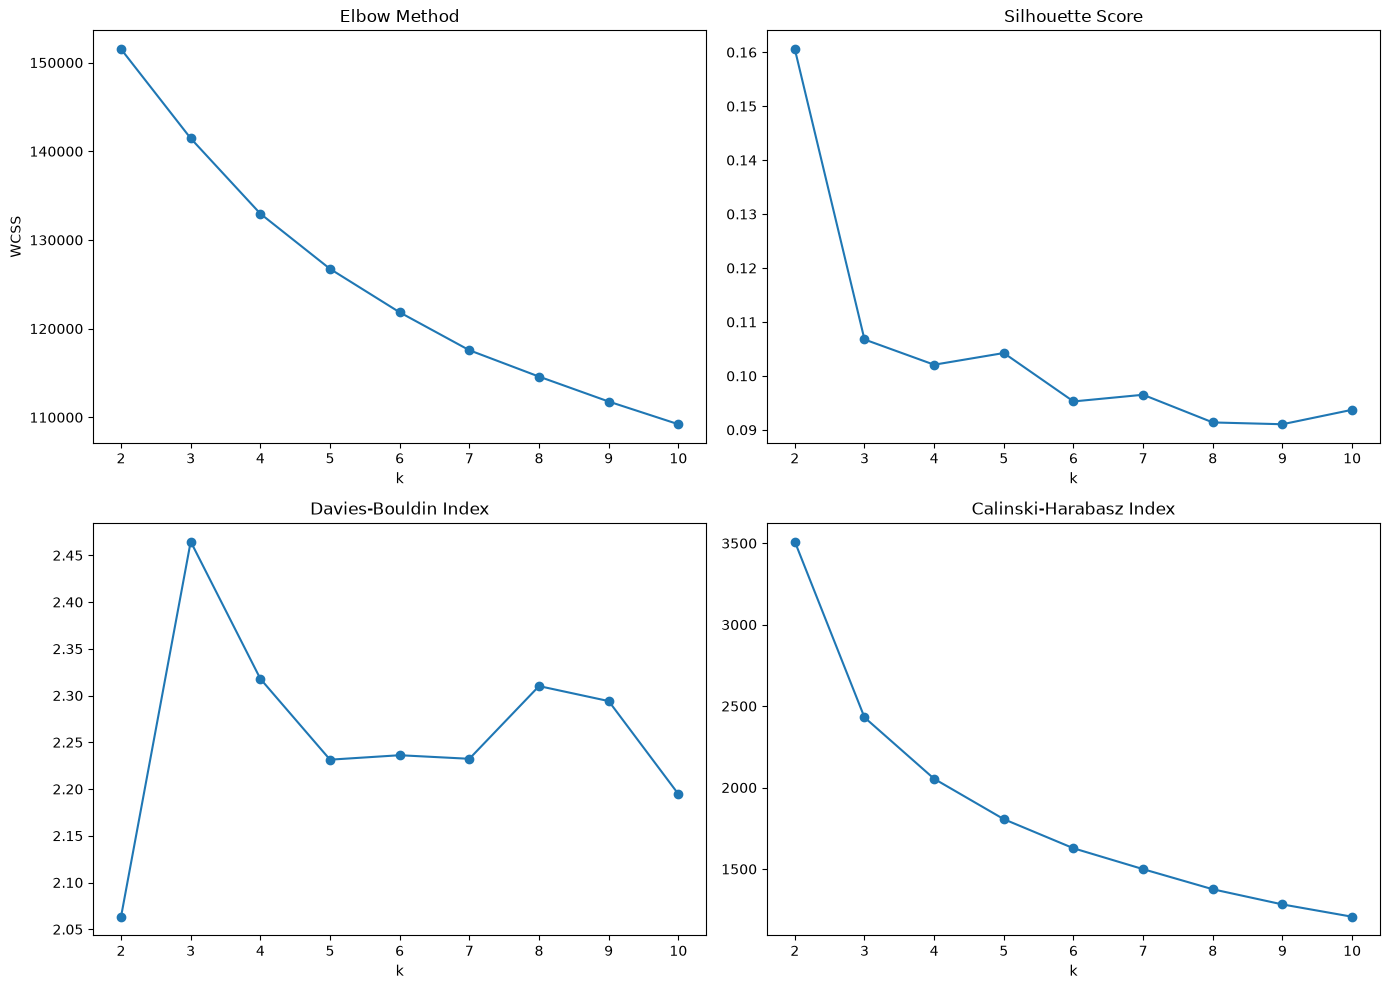

In [6]:


fig, axes = plt.subplots(2, 2, figsize=(14,10))

# WCSS
axes[0,0].plot(
    evaluation_df["k"],
    evaluation_df["WCSS"],
    marker="o"
)
axes[0,0].set_title("Elbow Method")
axes[0,0].set_xlabel("k")
axes[0,0].set_ylabel("WCSS")

# Silhouette
axes[0,1].plot(
    evaluation_df["k"],
    evaluation_df["Silhouette Score"],
    marker="o",
)
axes[0,1].set_title("Silhouette Score")
axes[0,1].set_xlabel("k")

# Davies
axes[1,0].plot(
    evaluation_df["k"],
    evaluation_df["Davies-Bouldin Index"],
    marker="o",
)
axes[1,0].set_title("Davies-Bouldin Index")
axes[1,0].set_xlabel("k")

# Calinski
axes[1,1].plot(
    evaluation_df["k"],
    evaluation_df["Calinski-Harabasz Index"],
    marker="o",
)
axes[1,1].set_title("Calinski-Harabasz Index")
axes[1,1].set_xlabel("k")

plt.tight_layout()

plt.show()

In [7]:
# ==========================================================
# Rank Each Metric
# ==========================================================

ranking_df = evaluation_df.copy()

ranking_df["Silhouette Rank"] = (
    ranking_df["Silhouette Score"]
    .rank(ascending=False)
)

ranking_df["Davies Rank"] = (
    ranking_df["Davies-Bouldin Index"]
    .rank(ascending=True)
)

ranking_df["CH Rank"] = (
    ranking_df["Calinski-Harabasz Index"]
    .rank(ascending=False)
)

ranking_df["Overall Rank"] = (

    ranking_df["Silhouette Rank"] +

    ranking_df["Davies Rank"] +

    ranking_df["CH Rank"]

)

ranking_df = ranking_df.sort_values("Overall Rank")

display(ranking_df.round(3))

,k,WCSS,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Silhouette Rank,Davies Rank,CH Rank,Overall Rank
0,2,151526.516,0.161,2.063,3509.939,1.0,1.0,1.0,3.0
3,5,126739.090,0.104,2.231,1805.982,3.0,3.0,4.0,10.0
1,3,141460.626,0.107,2.465,2430.700,2.0,9.0,2.0,13.0
2,4,132962.674,0.102,2.318,2053.810,4.0,8.0,3.0,15.0
5,7,117564.257,0.097,2.232,1499.156,5.0,4.0,6.0,15.0
4,6,121837.597,0.095,2.236,1627.386,6.0,5.0,5.0,16.0
8,10,109217.964,0.094,2.195,1207.033,7.0,2.0,9.0,18.0
6,8,114590.285,0.091,2.310,1375.650,8.0,7.0,7.0,22.0
7,9,111777.841,0.091,2.294,1282.587,9.0,6.0,8.0,23.0


After a thorough evaluation now we can conclude that we can train our model for k=2, k=5

In [8]:
# Fit Final KMeans Model (k = 2)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(scaled_df)

In [9]:
# Create Cluster Dataset

cluster_df = scaled_df.copy()

cluster_df["Cluster"] = cluster_labels

cluster_df.shape

(15489, 13)

In [10]:
# Cluster Size

cluster_counts = (

    cluster_df["Cluster"]
    .value_counts()
    .sort_index()

)

print(cluster_counts)

Cluster
0    7683
1    7806
Name: count, dtype: int64


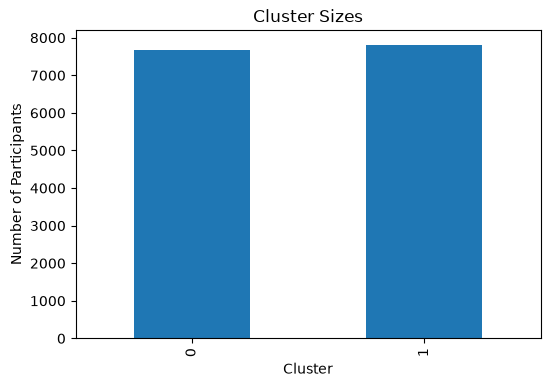

In [11]:
import matplotlib.pyplot as plt

cluster_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Participants")
plt.show()

In [12]:
# Cluster Centers

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=scaled_df.columns
)

display(
    centroids.round(3)
)

,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
0,-0.451,-0.405,0.077,-0.295,-0.457,-0.183,-0.537,-0.500,-0.432,-0.560,-0.532,0.479
1,0.444,0.398,-0.076,0.290,0.449,0.180,0.528,0.492,0.425,0.551,0.523,-0.471


In [13]:
# Add Cluster Labels to Original Feature Space

model_df = pd.read_csv("dataset//model_dataset.csv")
profile_df = model_df.copy()

profile_df["Cluster"] = cluster_labels

cluster_profile = (
    profile_df
    .groupby("Cluster")
    .mean()
)

# Cluster Profile before Normalization
display(cluster_profile.round(3))

,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
Cluster,,,,,,,,,,,,
0,3.731,1.968,1.447,1.600,4.302,1.435,0.277,0.474,0.520,0.366,0.501,0.502
1,6.698,3.453,1.371,1.859,7.096,1.778,0.479,0.699,0.665,0.607,0.684,0.318


,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
Cluster,,,,,,,,,,,,
0,0.373,0.394,0.447,0.600,0.43,0.478,0.277,0.474,0.520,0.366,0.501,0.502
1,0.670,0.691,0.371,0.859,0.71,0.593,0.479,0.699,0.665,0.607,0.684,0.318


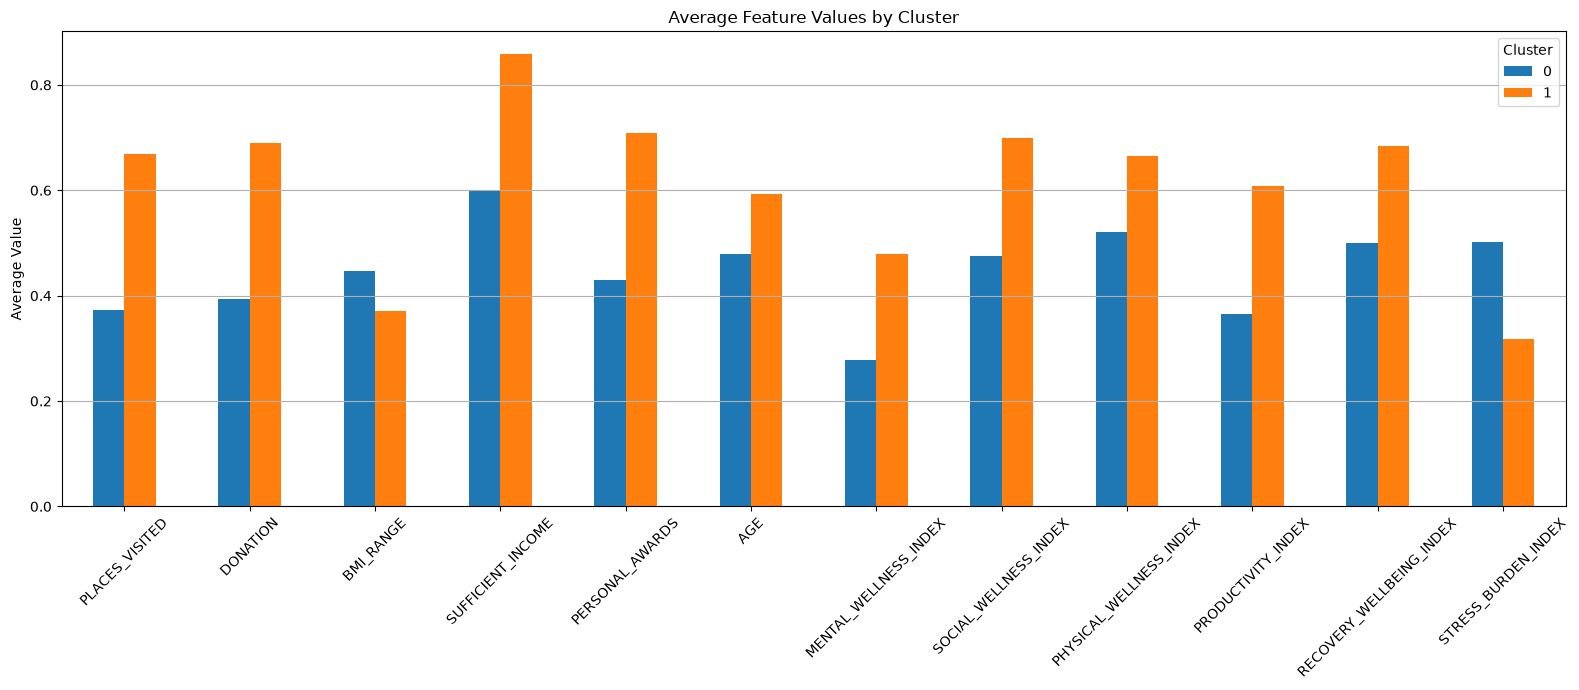

In [14]:
# ======================================================
# Cluster Profile Comparison
# ======================================================

from sklearn.preprocessing import MinMaxScaler

# Normalize Cluster Profiles ONLY for Visualization


visual_scaler = MinMaxScaler()

model_df_normalized = pd.DataFrame(
    visual_scaler.fit_transform(model_df),
    index=model_df.index,
    columns=model_df.columns
)

model_df_normalized["Cluster"] = cluster_labels

cluster_profile_normalized = (
    model_df_normalized
    .groupby("Cluster")
    .mean()
)

display(cluster_profile_normalized.round(3))

cluster_profile_normalized.T.plot(
    kind="bar", 
    figsize=(16,7)
)
plt.title("Average Feature Values by Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

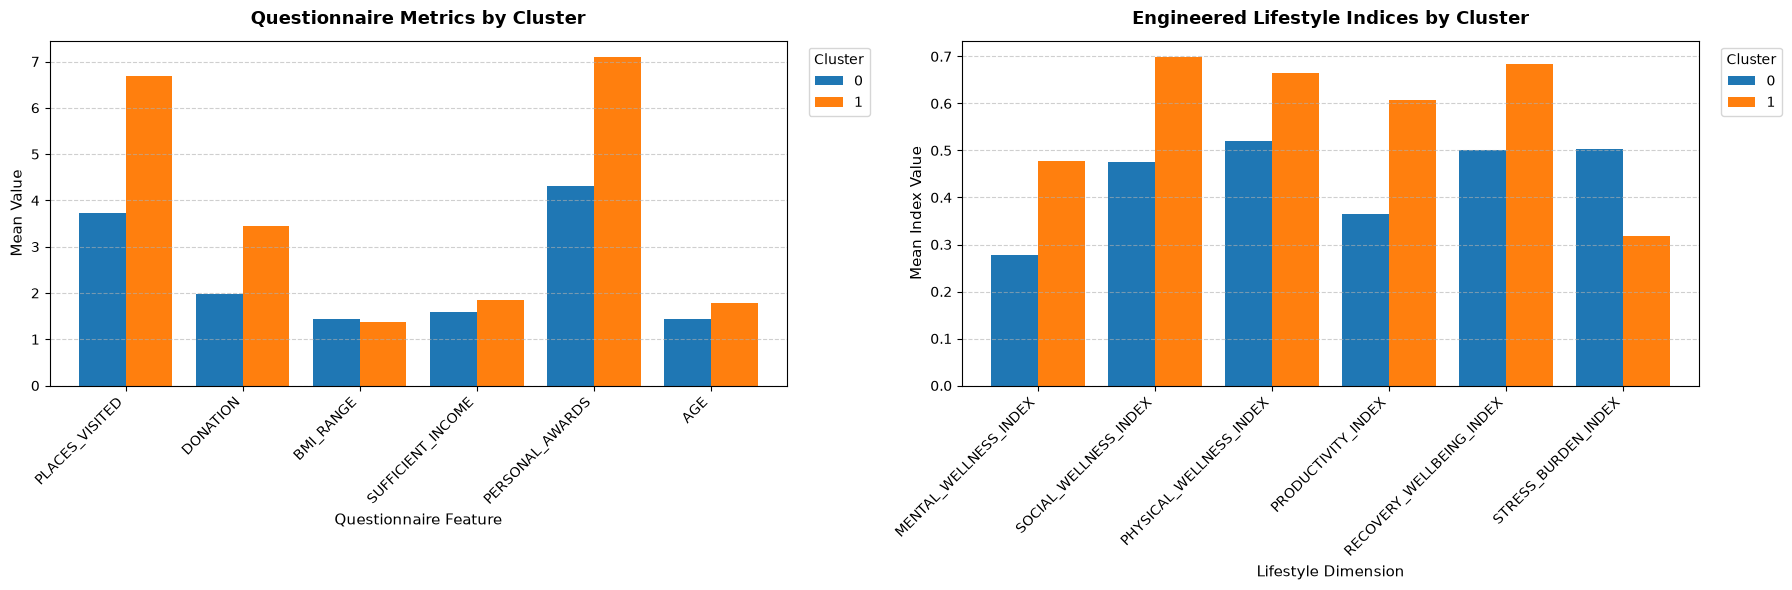

In [15]:
import matplotlib.pyplot as plt

# 1. Feature Subset Definition
engineered_features = [
    "MENTAL_WELLNESS_INDEX",
    "SOCIAL_WELLNESS_INDEX",
    "PHYSICAL_WELLNESS_INDEX",
    "PRODUCTIVITY_INDEX",
    "RECOVERY_WELLBEING_INDEX",
    "STRESS_BURDEN_INDEX"
]

questionnaire_features = [
    "PLACES_VISITED",
    "DONATION",
    "BMI_RANGE",
    "SUFFICIENT_INCOME",
    "PERSONAL_AWARDS",
    "AGE"
]

# 2. Extract Profiles
questionnaire_profile = cluster_profile[questionnaire_features]
engineered_profile = cluster_profile[engineered_features]

# 3. Plot Configurations
plot_configs = [
    {
        "df": questionnaire_profile,
        "title": "Questionnaire Metrics by Cluster",
        "xlabel": "Questionnaire Feature",
        "ylabel": "Mean Value"
    },
    {
        "df": engineered_profile,
        "title": "Engineered Lifestyle Indices by Cluster",
        "xlabel": "Lifestyle Dimension",
        "ylabel": "Mean Index Value"
    }
]

# 4. Render Side-by-Side Subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, config in zip(axes, plot_configs):
    config["df"].T.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )
    
    ax.set_title(config["title"], fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(config["xlabel"], fontsize=11)
    ax.set_ylabel(config["ylabel"], fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

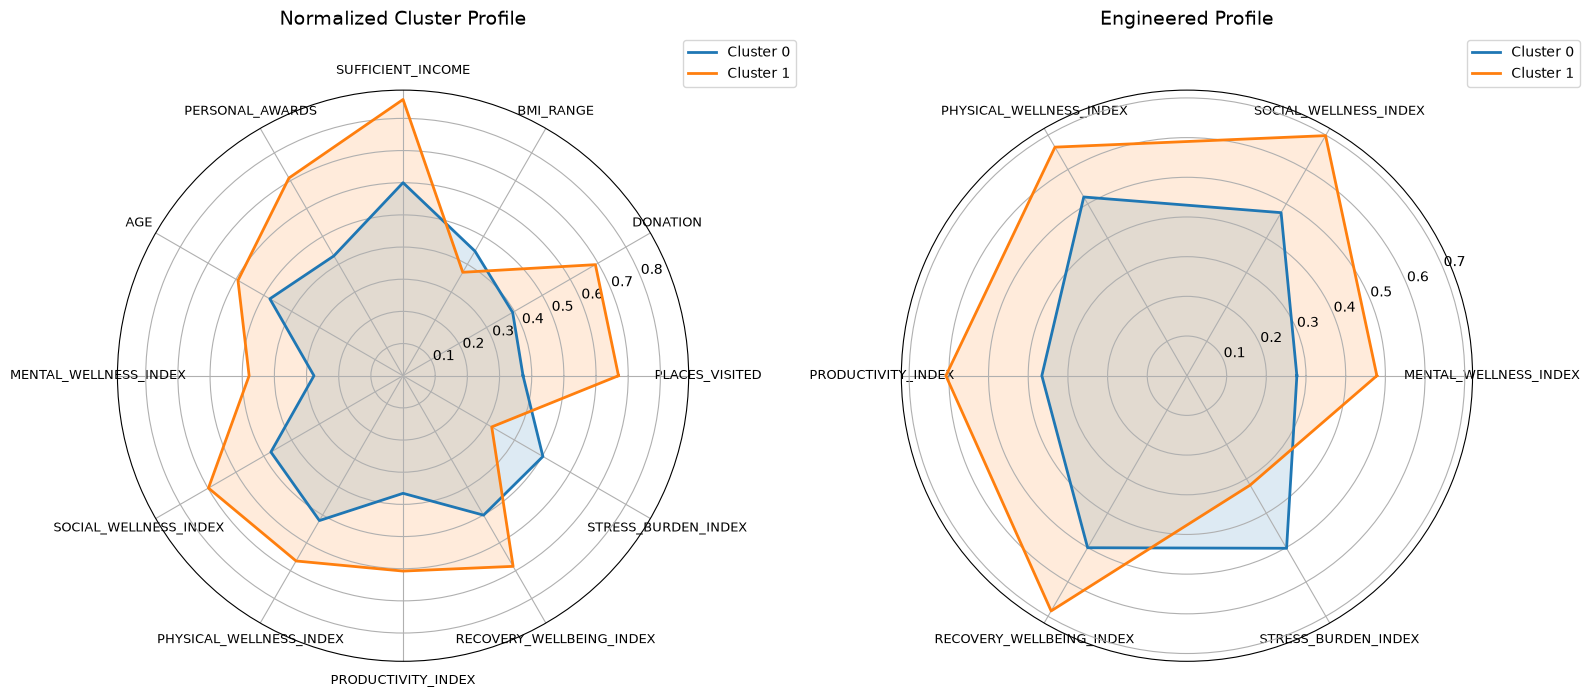

In [16]:
import numpy as np
import matplotlib.pyplot as plt

combi = [
    ("Normalized Cluster Profile", cluster_profile_normalized),
    ("Engineered Profile", engineered_profile)
]

# 1. Initialize subplots with polar projection enabled
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(polar=True))

for ax_idx, (title, clus) in enumerate(combi):
    ax = axes[ax_idx]
    labels = clus.columns.tolist()
    num_vars = len(labels)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Plot each cluster profile on the same polar axes
    for idx in clus.index:
        values = clus.loc[idx].tolist()
        values += values[:1]  # Close the loop

        ax.plot(
            angles,
            values,
            linewidth=2,
            label=f"Cluster {idx}"
        )
        ax.fill(
            angles,
            values,
            alpha=0.15
        )

    # Set feature labels along the perimeter
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, size=14, y=1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()


# PCA based clustering

In [17]:
# ======================================================
# Load PCA Features
# ======================================================

import pandas as pd
import numpy as np

pca_df = pd.read_csv("dataset//pca_features.csv")

print("PCA Dataset Shape:", pca_df.shape)

display(pca_df.head())

PCA Dataset Shape: (15489, 3)


,PC1,PC2,PC3
0,-2.250030,-0.851620,-0.225671
1,-0.252660,0.350090,1.074253
2,-1.325374,0.710167,1.100192
3,-1.387742,2.660277,0.174119
4,0.550012,0.864304,1.920933


In [18]:
# ======================================================
# K-Means on PCA Features
# ======================================================

from sklearn.cluster import KMeans

pca_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

pca_labels = pca_kmeans.fit_predict(pca_df)

In [19]:
# ======================================================
# Evaluate PCA Clustering
# ======================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

pca_silhouette = silhouette_score(
    pca_df,
    pca_labels
)

pca_davies = davies_bouldin_score(
    pca_df,
    pca_labels
)

pca_calinski = calinski_harabasz_score(
    pca_df,
    pca_labels
)

print("PCA Clustering Results")
print("-" * 40)

print(f"Silhouette Score       : {pca_silhouette:.4f}")
print(f"Davies-Bouldin Index   : {pca_davies:.4f}")
print(f"Calinski-Harabasz      : {pca_calinski:.4f}")

PCA Clustering Results
----------------------------------------
Silhouette Score       : 0.3034
Davies-Bouldin Index   : 1.2439
Calinski-Harabasz      : 8670.2324


In [20]:
# ======================================================
# Compare Original vs PCA
# ======================================================

original_k2 = evaluation_df[
    evaluation_df["k"] == 2
].iloc[0]

comparison_df = pd.DataFrame({

    "Representation": [
        "Original Features",
        "PCA (3 Components)"
    ],

    "Number of Features": [
        scaled_df.shape[1],
        pca_df.shape[1]
    ],

    "Silhouette Score": [
        original_k2["Silhouette Score"],
        pca_silhouette
    ],

    "Davies-Bouldin Index": [
        original_k2["Davies-Bouldin Index"],
        pca_davies
    ],

    "Calinski-Harabasz Index": [
        original_k2["Calinski-Harabasz Index"],
        pca_calinski
    ]
})

display(comparison_df.round(4))

,Representation,Number of Features,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,Original Features,12,0.1606,2.0634,3509.9391
1,PCA (3 Components),3,0.3034,1.2439,8670.2324


![image](Images/image.png)

In [21]:
# ======================================================
# Compare Cluster Assignments
# ======================================================

from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    cluster_labels,
    pca_labels
)

print(
    f"Adjusted Rand Index: {ari_score:.4f}"
)

Adjusted Rand Index: 0.9910


|      ARI | Interpretation                |
| -------: | ----------------------------- |
|      1.0 | Identical clustering          |
| ~0.7–1.0 | Very strong agreement         |
| ~0.4–0.7 | Moderate/strong agreement     |
|     ~0.0 | Little agreement              |
|       <0 | Worse than expected by chance |


In [22]:
centroid_difference = (
    centroids.loc[1] - centroids.loc[0]
).abs().sort_values(ascending=False)

display(
    centroid_difference.to_frame(
        "Absolute Centroid Difference"
    )
)

,Absolute Centroid Difference
PRODUCTIVITY_INDEX,1.111735
MENTAL_WELLNESS_INDEX,1.064580
RECOVERY_WELLBEING_INDEX,1.055097
SOCIAL_WELLNESS_INDEX,0.991544
STRESS_BURDEN_INDEX,0.950864
PERSONAL_AWARDS,0.906106
PLACES_VISITED,0.895434
PHYSICAL_WELLNESS_INDEX,0.856935
DONATION,0.803013
SUFFICIENT_INCOME,0.584636


# Original k = 5

In [23]:
# ======================================================
# Original Features: k = 5
# ======================================================

original_k5 = evaluation_df[
    evaluation_df["k"] == 5
].iloc[0]

print("Original Features - k = 5")
print("-" * 40)

print(f"Silhouette Score     : {original_k5['Silhouette Score']:.4f}")
print(f"Davies-Bouldin Index : {original_k5['Davies-Bouldin Index']:.4f}")
print(f"Calinski-Harabasz    : {original_k5['Calinski-Harabasz Index']:.4f}")

Original Features - k = 5
----------------------------------------
Silhouette Score     : 0.1042
Davies-Bouldin Index : 2.2314
Calinski-Harabasz    : 1805.9825


# PCA k = 5

In [24]:
# ======================================================
# PCA Features: k = 5
# ======================================================

pca_kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

pca_labels_5 = pca_kmeans_5.fit_predict(pca_df)

pca_silhouette_5 = silhouette_score(
    pca_df,
    pca_labels_5
)

pca_davies_5 = davies_bouldin_score(
    pca_df,
    pca_labels_5
)

pca_calinski_5 = calinski_harabasz_score(
    pca_df,
    pca_labels_5
)

print("PCA Features - k = 5")
print("-" * 40)

print(f"Silhouette Score     : {pca_silhouette_5:.4f}")
print(f"Davies-Bouldin Index : {pca_davies_5:.4f}")
print(f"Calinski-Harabasz    : {pca_calinski_5:.4f}")

PCA Features - k = 5
----------------------------------------
Silhouette Score     : 0.2434
Davies-Bouldin Index : 1.1433
Calinski-Harabasz    : 6053.4549


# Everything into one table

In [25]:
# ======================================================
# Final Representation Comparison
# ======================================================

final_comparison = pd.DataFrame({

    "Representation": [
        "Original - k=2",
        "PCA - k=2",
        "Original - k=5",
        "PCA - k=5"
    ],

    "Features": [
        12,
        3,
        12,
        3
    ],

    "k": [
        2,
        2,
        5,
        5
    ],

    "Silhouette": [
        original_k2["Silhouette Score"],
        pca_silhouette,
        original_k5["Silhouette Score"],
        pca_silhouette_5
    ],

    "Davies-Bouldin": [
        original_k2["Davies-Bouldin Index"],
        pca_davies,
        original_k5["Davies-Bouldin Index"],
        pca_davies_5
    ],

    "Calinski-Harabasz": [
        original_k2["Calinski-Harabasz Index"],
        pca_calinski,
        original_k5["Calinski-Harabasz Index"],
        pca_calinski_5
    ]
})

display(final_comparison.round(4))

,Representation,Features,k,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,Original - k=2,12,2,0.1606,2.0634,3509.9391
1,PCA - k=2,3,2,0.3034,1.2439,8670.2324
2,Original - k=5,12,5,0.1042,2.2314,1805.9825
3,PCA - k=5,3,5,0.2434,1.1433,6053.4549


<h3>Here we can conclude that 3 dimensions of pca when performed with k=2 outperformed on all metrics except davies bouldin. Hence this clustering can divide the dataset into two distinct clusters.The two clusters may be of healthy well being and unhealthy well being</h3>

In [26]:
final_comparison

,Representation,Features,k,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,Original - k=2,12,2,0.160574,2.063402,3509.939149
1,PCA - k=2,3,2,0.303382,1.243947,8670.232358
2,Original - k=5,12,5,0.104242,2.231403,1805.982490
3,PCA - k=5,3,5,0.243386,1.143328,6053.454878
